# Carleton campus evacuation

This notebook helps you **run one evacuation scenario** and **look at the results**.

### What you will do

1. Choose a scenario (1–7)
2. Optionally run the MARS simulation
3. View a summary and evacuation charts
4. (Later) Compare those results with the DEVS model

### Scenario guide

| # | What changes |
|---|--------------|
| **1** | Baseline — all parking lots start deploying at the same time |
| **2** | Lot P6 starts 1 hour later |
| **3** | Lot P6 starts 2 hours later |
| **4** | Lot P3 delayed 1 hour; P6 delayed 2 hours |
| **5** | Lots P3 and P4 delayed 1 hour; P6 delayed 2 hours |
| **6** | Lots P3 and P4 delayed 1 hour; P6 delayed 1.5 hours |
| **7** | Same timing as baseline, P3 & P4 Exit Via Emergency Exit |

### Before you start (one-time setup)

Open a terminal and run:

```bash
cd /Users/dorian/Projects/model-soh/CarletonDrivingBox
source .venv/bin/activate
pip install -r requirements.txt
python -m ipykernel install --user --name=carleton-driving --display-name="Carleton Driving"
jupyter notebook analyze_scenario.ipynb
```

When Jupyter asks which kernel to use, pick **Carleton Driving**.

> **Tip:** Running a full simulation can take a long time and creates large files.  
> If you already have results, leave `RUN_SIMULATION = False` and jump straight to the charts.

## Step 1 — Prepare the notebook

This cell finds the project folder and loads a few helpers.  
Run it once at the start of each session.

In [8]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

from IPython.display import Image, Markdown, display

# Find the CarletonDrivingBox project folder
ROOT = Path.cwd()
if not (ROOT / "SOHCarletonDrivingBox.csproj").is_file():
    candidate = ROOT / "CarletonDrivingBox"
    if (candidate / "SOHCarletonDrivingBox.csproj").is_file():
        ROOT = candidate

SCRIPTS = ROOT / "scripts"
RESULTS = ROOT / "results"
CONFIGS = ROOT / "configs"
PROJECT = "SOHCarletonDrivingBox.csproj"
SCENARIOS = tuple(range(1, 8))

sys.path.insert(0, str(SCRIPTS))
from mars_agent_outputs import agent_output_path  # noqa: E402


def run_cmd(cmd: list[str], *, quiet: bool = False, label: str | None = None) -> None:
    """Run a shell command from the project folder and stop if it fails.

    quiet=True hides noisy build warnings and only prints a short status.
    On failure, the full output is still shown so you can debug.
    """
    if label:
        print(label, flush=True)
    elif not quiet:
        print("Running:", " ".join(cmd), flush=True)

    env = {**os.environ, "DOTNET_NOLOGO": "1"}
    completed = subprocess.run(
        cmd,
        cwd=ROOT,
        env=env,
        capture_output=quiet,
        text=True,
    )
    if completed.returncode != 0:
        details = ""
        if quiet:
            details = "\n" + (completed.stdout or "") + (completed.stderr or "")
        raise RuntimeError(
            f"That command failed (exit code {completed.returncode}).\n"
            f"Command: {' '.join(cmd)}"
            f"{details}"
        )
    if quiet:
        print("  done.", flush=True)


print(f"Ready. Project folder:\n  {ROOT}")
assert (ROOT / PROJECT).is_file(), (
    "Could not find SOHCarletonDrivingBox.csproj.\n"
    "Open this notebook from inside the CarletonDrivingBox folder."
)


Ready. Project folder:
  /Users/dorian/Projects/model-soh/CarletonDrivingBox


## Step 2 — Choose your scenario

Edit the two settings below, then run the cell.

| Setting | What it means |
|---------|----------------|
| `SCENARIO` | Which scenario to use (`1` through `7`) |
| `RUN_SIMULATION` | `True` = run a new simulation first (slow). `False` = only look at results you already have |

Results are stored in `results/scenario_01/` … `results/scenario_07/`.

In [9]:
# --- Edit these ---
SCENARIO = 7            # pick 1, 2, 3, 4, 5, 6, or 7
RUN_SIMULATION = True  # True = run MARS now; False = reuse existing results
BUILD_FIRST = True      # rebuild the C# project before running (recommended)
# ------------------

assert SCENARIO in SCENARIOS, f"Please choose a scenario from 1 to 7 (you chose {SCENARIO})."

SID = f"{SCENARIO:02d}"
CONFIG = CONFIGS / f"config_scenario_{SID}.json"
OUT_DIR = RESULTS / f"scenario_{SID}"
CSV_PATH = agent_output_path(OUT_DIR, ".csv")
TRIPS_PATH = agent_output_path(OUT_DIR, "_trips.geojson")

assert CONFIG.is_file(), f"Config file not found:\n  {CONFIG}"

cfg = json.loads(CONFIG.read_text(encoding="utf-8"))
start = cfg["globals"]["startPoint"]
end = cfg["globals"]["endPoint"]
out_path = cfg["globals"]["csvOptions"]["outputPath"]

print("Your selection")
print("--------------")
print(f"  Scenario          : {SCENARIO}  (folder: scenario_{SID})")
print(f"  Config file       : {CONFIG.relative_to(ROOT)}")
print(f"  Simulation window : {start}  →  {end}")
print(f"  Results go to     : {out_path}/")
print()
print("What already exists?")
print("--------------------")
print(f"  Agent CSV         : {'yes' if CSV_PATH.is_file() else 'no '}  ({CSV_PATH.name})")
print(f"  Trips GeoJSON     : {'yes' if TRIPS_PATH.is_file() else 'no '}  ({TRIPS_PATH.name})")
print()
if RUN_SIMULATION:
    print("Next step: this notebook will run a new simulation.")
else:
    print("Next step: this notebook will analyze existing results (no new simulation).")

Your selection
--------------
  Scenario          : 7  (folder: scenario_07)
  Config file       : configs/config_scenario_07.json
  Simulation window : 2021-10-11T06:00:00  →  2021-10-11T10:01:00
  Results go to     : results/scenario_07/

What already exists?
--------------------
  Agent CSV         : yes  (CarletonCarDriver.csv)
  Trips GeoJSON     : yes  (CarletonCarDriver_trips.geojson)

Next step: this notebook will run a new simulation.


## Step 3 — Run the simulation (optional)

Only needed when `RUN_SIMULATION = True`.

This starts the MARS model for your chosen scenario. When it finishes, you should see two main files in the results folder:

- **`CarletonCarDriver.csv`** — tick-by-tick state of every car
- **`CarletonCarDriver_trips.geojson`** — completed trip paths

You need the .NET SDK installed for this step.

The build step is kept quiet on purpose (those long NuGet/C# warning lists are hidden). If the build fails, the full error output is still shown.

> If `RUN_SIMULATION = False`, this cell simply skips the run and tells you what it found.

In [15]:
if RUN_SIMULATION:
    print(f"Starting scenario {SCENARIO}…")
    print("This can take a while. Leave the cell running until it finishes.\n")

    if BUILD_FIRST:
        # Quiet build: hide NuGet/C# warning spam; still fails loudly on errors
        run_cmd(
            [
                "dotnet",
                "build",
                PROJECT,
                "-v",
                "q",
                "/p:NuGetAudit=false",
                "/clp:ErrorsOnly",
            ],
            quiet=True,
            label="Building the project…",
        )

    cmd = ["dotnet", "run", "--no-launch-profile", "--project", PROJECT]
    if BUILD_FIRST:
        cmd.insert(2, "--no-build")
    cmd += ["--", str(CONFIG.relative_to(ROOT))]

    # Simulation output is short (folder + duration) — show it live
    print("Running the simulation…")
    run_cmd(cmd)
    print(f"\nFinished. Results are in:\n  {OUT_DIR}")
else:
    print("Simulation skipped (RUN_SIMULATION is False).")
    if CSV_PATH.is_file():
        print(f"Using existing results in:\n  {OUT_DIR}")
    else:
        print(
            "\nNo results found for this scenario yet.\n"
            "To create them, set RUN_SIMULATION = True in Step 2 and run Steps 2–3 again.\n"
            f"Or from a terminal:\n"
            f"  python scripts/run_all_scenarios.py {SID}"
        )

Starting scenario 7…
This can take a while. Leave the cell running until it finishes.

Building the project…
  done.
Running the simulation…
Running: dotnet run --no-build --no-launch-profile --project SOHCarletonDrivingBox.csproj -- configs/config_scenario_07.json
Output folder: /Users/dorian/Projects/model-soh/CarletonDrivingBox/results/scenario_07
Executed iterations 14460 lasted 00:00:53.3243235

Finished. Results are in:
  /Users/dorian/Projects/model-soh/CarletonDrivingBox/results/scenario_07


## Step 4 — Analyze the results

This cell reads the simulation output and builds:

- a short **summary** (how many cars were expected vs how many finished)
- a **deployment chart** (`summary.png`)
- an **evacuation curve** (`evac_curve.png`) — cars still on campus over time

Everything is saved next to the simulation files in `results/scenario_XX/`.

Analyzing scenario 7…

Running: /Users/dorian/Projects/model-soh/CarletonDrivingBox/.venv/bin/python3.14 /Users/dorian/Projects/model-soh/CarletonDrivingBox/scripts/analyze_run.py /Users/dorian/Projects/model-soh/CarletonDrivingBox/results/scenario_07/CarletonCarDriver.csv
Project root : /Users/dorian/Projects/model-soh/CarletonDrivingBox
Output dir   : /Users/dorian/Projects/model-soh/CarletonDrivingBox/results/scenario_07
Trips file   : /Users/dorian/Projects/model-soh/CarletonDrivingBox/results/scenario_07/CarletonCarDriver_trips.geojson (found)
CSV file     : /Users/dorian/Projects/model-soh/CarletonDrivingBox/results/scenario_07/CarletonCarDriver.csv (found)
Schedule     : /Users/dorian/Projects/model-soh/CarletonDrivingBox/resources/schedules/scenario_07_schedule.csv
Config       : /Users/dorian/Projects/model-soh/CarletonDrivingBox/configs/config_scenario_07.json
Trips geojson: 277,278,309 bytes | feature scan=3232 | exit timestamps=3232
Using CarletonCarDriver.csv for on-campus

### Summary numbers

expected_deployed,baseline_target,completed_trips_geojson,completed_unique_ids_csv,goal_reached_rows_csv,completion_rate_pct,csv_tick_rows,evac_end_s
3200,3200,3232,3232,3232,101.0,7105525,10638



### Deployment vs completion

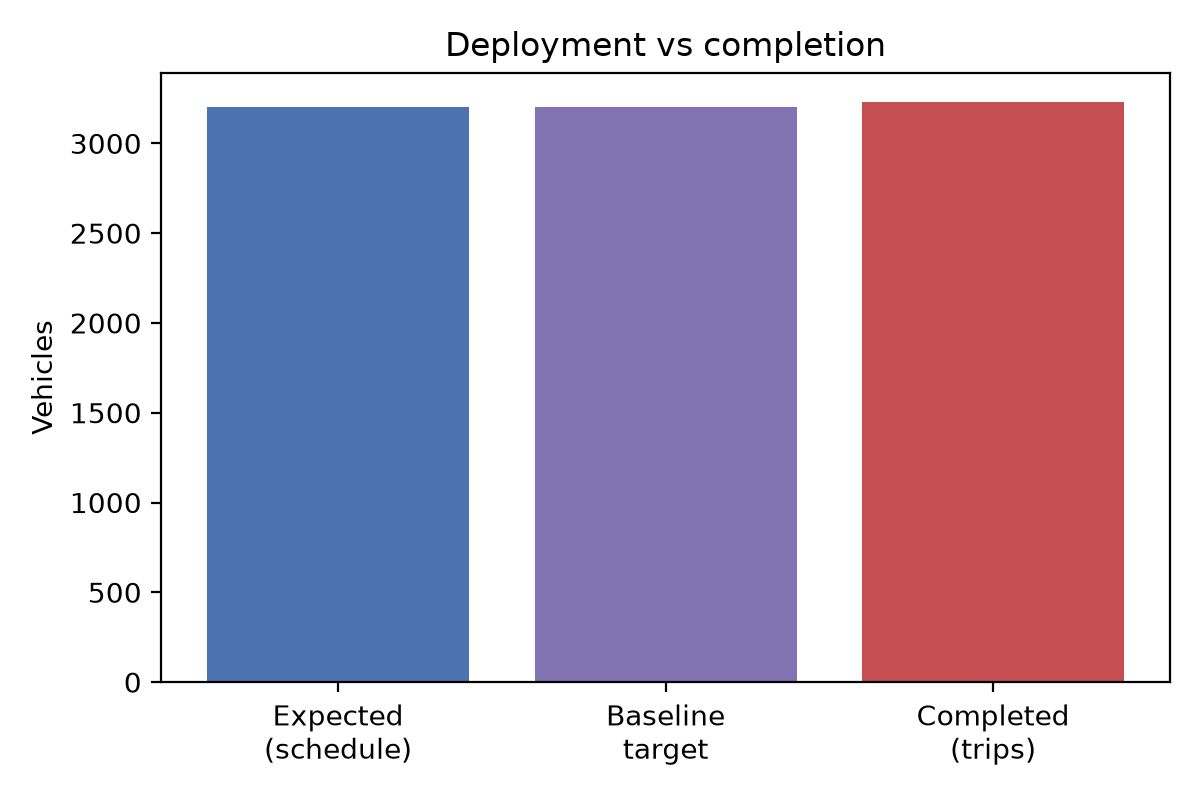

### Evacuation curve (cars still on campus)

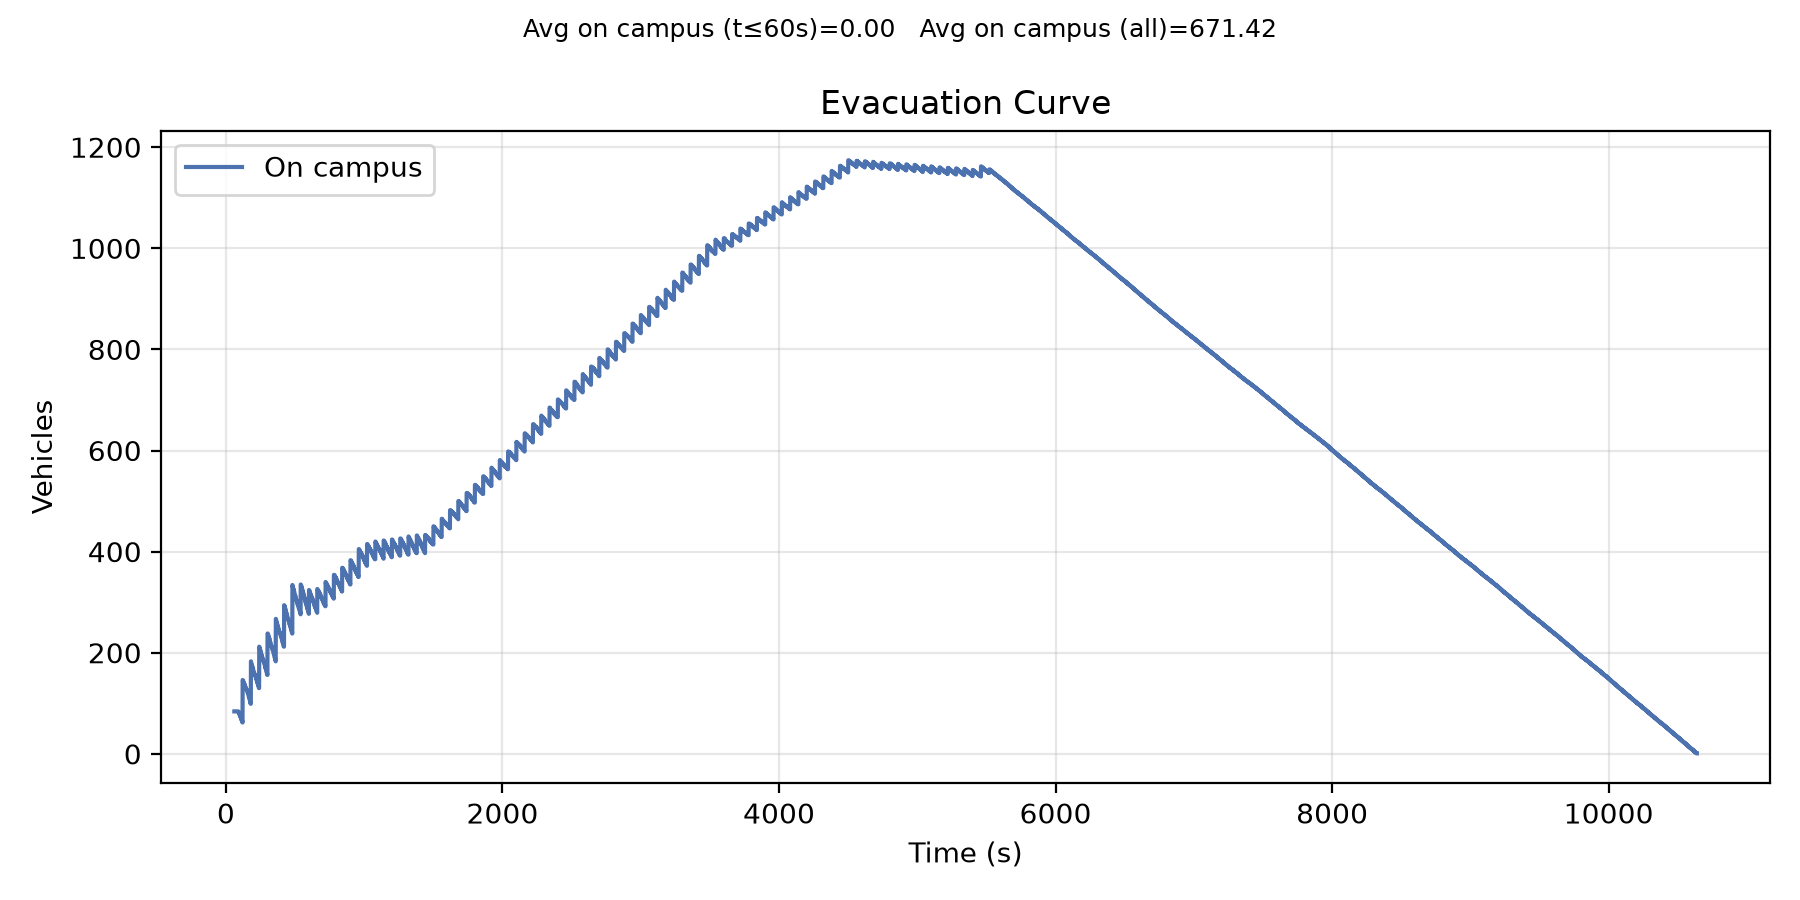

In [18]:
CSV_PATH = agent_output_path(OUT_DIR, ".csv")
TRIPS_PATH = agent_output_path(OUT_DIR, "_trips.geojson")

if not CSV_PATH.is_file():
    raise FileNotFoundError(
        f"Cannot analyze yet — no agent CSV found at:\n  {CSV_PATH}\n\n"
        "Run the simulation first (set RUN_SIMULATION = True in Step 2)."
    )

print(f"Analyzing scenario {SCENARIO}…\n")
run_cmd([sys.executable, str(SCRIPTS / "analyze_run.py"), str(CSV_PATH)])

summary_csv = OUT_DIR / "summary.csv"
if summary_csv.is_file():
    display(Markdown("### Summary numbers"))
    print(summary_csv.read_text(encoding="utf-8"))

plot_titles = {
    "summary.png": "### Deployment vs completion",
    "evac_curve.png": "### Evacuation curve (cars still on campus)",
}
for name, title in plot_titles.items():
    path = OUT_DIR / name
    if path.is_file():
        display(Markdown(title))
        display(Image(filename=str(path)))
    else:
        print(f"Chart not found: {path.name}")

## Step 5 — What’s in the results folder?

A quick list of the files produced for this scenario, with file sizes.

In [19]:
def format_size(size: int) -> str:
    if size >= 1_000_000_000:
        return f"{size / 1_000_000_000:.2f} GB"
    if size >= 1_000_000:
        return f"{size / 1_000_000:.1f} MB"
    if size >= 1_000:
        return f"{size / 1_000:.1f} KB"
    return f"{size} B"


if OUT_DIR.is_dir():
    lines = [f"**Folder:** `{OUT_DIR.relative_to(ROOT)}/`", ""]
    for path in sorted(OUT_DIR.iterdir()):
        lines.append(f"- `{path.name}` — {format_size(path.stat().st_size)}")
    display(Markdown("\n".join(lines)))
else:
    print(f"No results folder yet for scenario {SCENARIO}:\n  {OUT_DIR}")

**Folder:** `results/scenario_07/`

- `CarletonCarDriver.csv` — 1.41 GB
- `CarletonCarDriver_trips.geojson` — 277.3 MB
- `evac_curve.csv` — 319.6 KB
- `evac_curve.png` — 82.7 KB
- `lot_deploy_plan.csv` — 123 B
- `summary.csv` — 197 B
- `summary.png` — 35.6 KB

## Step 6 — Compare with DEVS (coming soon)

This section is a placeholder for a future side-by-side comparison with the DEVS model.

When DEVS outputs are available for the same scenario, we plan to compare:

- how many cars finished the trip
- the evacuation curve (cars still on campus over time)
- how long it took for the campus to clear

For reference, the MARS baseline target is **3,200** vehicles.

Expected layout later: `devs/scenario_01/` … `devs/scenario_07/`.

In [ ]:
DEVS_DIR = ROOT / "devs" / f"scenario_{SID}"

print("Comparison status")
print("-----------------")
print(f"  MARS results : {OUT_DIR.relative_to(ROOT)}/")
print(f"  DEVS results : {DEVS_DIR.relative_to(ROOT)}/")
print(f"  DEVS folder  : {'found' if DEVS_DIR.is_dir() else 'not found yet'}")
print()
print("Next: once DEVS outputs exist for this scenario, we can overlay the curves here.")